Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import random

In [13]:
#Obtiene contornos con el operador de Canny
img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)
sobel8 = cv2.convertScaleAbs(sobel)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Tarea 1: Análisis de Densidad de Bordes con Canny (Por Filas)

Valor máximo de píxeles blancos en una fila (maxfil): 220.0
Número de filas que cumplen la condición: 7
Posiciones exactas de dichas filas: [  6  12  15  20  21  88 100]


<Figure size 1200x500 with 0 Axes>

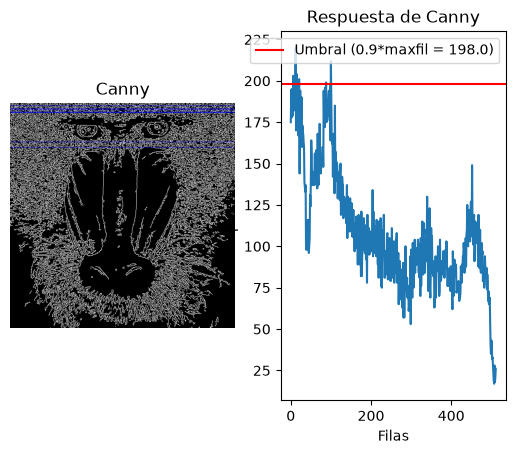

In [ ]:
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)
#Cuenta el número de píxeles blancos (255) por fila
#Suma los valores de los pixeles por fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por fila
rows = row_counts.flatten() / 255

maxfil = np.max(rows)
umbral = 0.90 * maxfil
posiciones = np.where(rows >= umbral)[0]
num_filas = len(posiciones)

print(f"Valor máximo de píxeles blancos en una fila (maxfil): {maxfil}")
print(f"Número de filas que cumplen la condición: {num_filas}")
print(f"Posiciones exactas de dichas filas: {posiciones}")

# Convertimos la imagen Canny a BGR para poder pintar líneas a color (rojo) sobre ella
canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)

# Dibujamos una línea horizontal roja de extremo a extremo en cada fila detectada
for y in posiciones:
    cv2.line(canny_color, (0, y), (canny.shape[1], y), (255, 0, 0), 1)
    
plt.figure(figsize=(12, 5))

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 
plt.imshow(cv2.cvtColor(canny_color, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)

# Dibuja una línea horizontal indicando dónde está el umbral del 90%
plt.axhline(y=umbral, color='r', linestyle='-', label=f'Umbral (0.9*maxfil = {umbral:.1f})')
plt.legend()

#Rango en x definido por las columnas
plt.xlim([0, canny.shape[0]])

Tarea 2: Análisis de Bordes con Sobel y Canny (Imagen del Mandril).  En esta tarea hemos implementado un algoritmo para detectar y resaltar automáticamente las zonas con mayor densidad de bordes o texturas en una imagen, comparando los resultados entre distintos operadores.

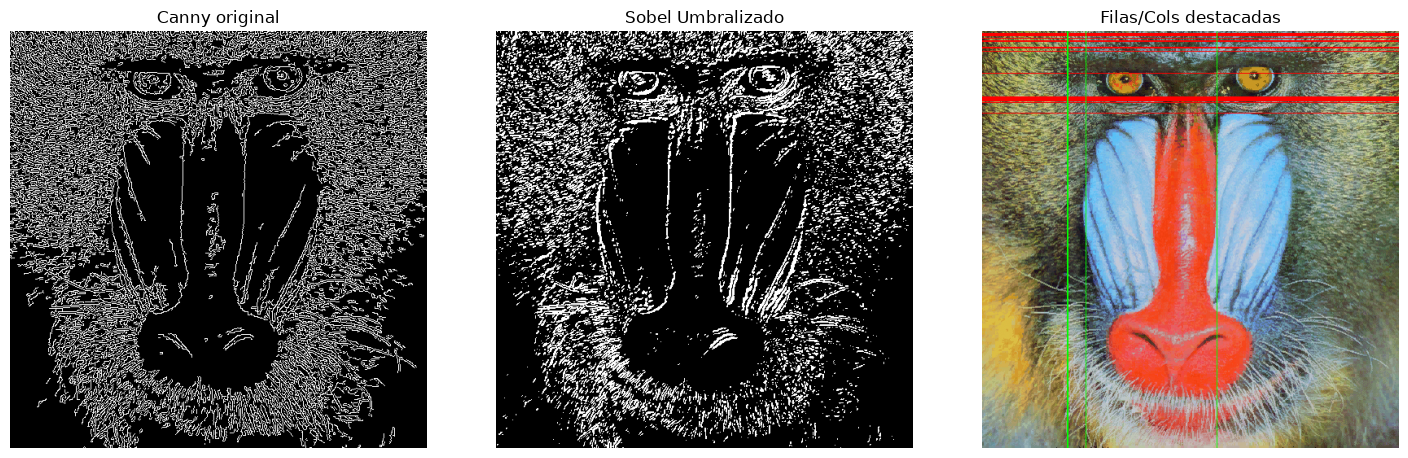

In [14]:
## Define valor umbral
valorUmbral = 100
## Obtiene imagen umbralizada para dicho valor definido, pero usando sobel8
_, sobel_umbral = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)


## Cuenta el número de píxeles blancos (255) por columna y por fila
## Suma los valores de los pixeles por columna (0) y por fila (1)
col_counts = cv2.reduce(sobel_umbral, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
row_counts = cv2.reduce(sobel_umbral, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

## El resultado será el número de píxeles blancos puros
cols = col_counts[0] / 255
rows = row_counts[:, 0] / 255


## Calcula el valor máximo de la cuenta por filas y columnas
maxcol = np.max(cols)
maxfil = np.max(rows)

## Hacemos una copia de la imagen a color para dibujar encima
img_resultado = img_rgb.copy()

## Recorremos las filas. Si supera el 0.90*máximo, dibujamos una primitiva (línea)
for f in range(len(rows)):
    if rows[f] >= 0.90 * maxfil:
        # cv2.line(imagen, inicio, fin, color(R,G,B), grosor)
        cv2.line(img_resultado, (0, f), (img_resultado.shape[1], f), (255, 0, 0), 1)

## Recorremos las columnas. Si supera el 0.90*máximo, dibujamos una primitiva (línea)
for c in range(len(cols)):
    if cols[c] >= 0.90 * maxcol:
        cv2.line(img_resultado, (c, 0), (c, img_resultado.shape[0]), (0, 255, 0), 1)


## Muestra ambos resultados comparativos
## Ampliamos el tamaño de la figura (ancho, alto en pulgadas)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('Canny original')
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('Sobel Umbralizado')
plt.imshow(sobel_umbral, cmap='gray') 

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Filas/Cols destacadas')
plt.imshow(img_resultado) 

## Ajusta automáticamente la separación entre gráficos
plt.tight_layout(pad=3.0) 
plt.show()

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [15]:
vid = cv2.VideoCapture(0)

fotograma_anterior = None
pelotas = []

umbral_movimiento = 0.075
umbral_pixels = 25
tiempo_entre_pelotas = 0.8
radio_pelota = 18

ultimo_movimiento = 0
movimiento_anterior = False
fotogramas_inicio = 0
maximo_pelotas = 20

while True:
    ret, frame = vid.read()
    
    if  ret:
        frame = cv2.flip(frame, 1)
        fotogramas_inicio += 1 
        alto, ancho = frame.shape[:2]
        ancho_mitad = ancho // 2

        #Pasamos la imagen a escala de grices y eliminamos el ruido
        gris_actual = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gris_actual = cv2.GaussianBlur(gris_actual, (5, 5), 0)

        proporciones = [0.0, 0.0]
        zonas_movimiento = []

        if fotograma_anterior is not None:
            diferencia = cv2.absdiff(gris_actual, fotograma_anterior)

            _, mascara_movimiento = cv2.threshold(diferencia, umbral_pixels, 255, cv2.THRESH_BINARY)

            mascara_movimiento = cv2.morphologyEx(mascara_movimiento,
                cv2.MORPH_OPEN,
                np.ones((3, 3), np.uint8))

            
            #Define cada zona de la imagen (izquierda y derecha) para detectar movimiento
            zona_izq = mascara_movimiento[:, :ancho_mitad]
            zona_der = mascara_movimiento[:, ancho_mitad:]
            
            #Detecta el movimiento en cada zona y calcula la proporción de píxeles blancos respecto al total de píxeles de la zona
            proporciones[0] = np.count_nonzero(zona_izq) / zona_izq.size
            proporciones[1] = np.count_nonzero(zona_der) / zona_der.size

            contornos = cv2.findContours(mascara_movimiento, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[-2]

            for contorno in contornos:
                area = cv2.contourArea(contorno)
                if 250 < area < (ancho * alto * 0.15):
                    x, y, w, h = cv2.boundingRect(contorno)
                    cx = x + w // 2
                    cy = y + h // 2
                    zonas_movimiento.append((x, y, x + w, y + h, cx, cy, area))

            lado_activo = int(np.argmax(proporciones))
            
            hay_movimiento = True if proporciones[lado_activo] >= umbral_movimiento else False
            
            movimiento_actual = cv2.getTickCount() / cv2.getTickFrequency()

            if (hay_movimiento and not movimiento_anterior and fotogramas_inicio > 30
                and movimiento_actual - ultimo_movimiento >= tiempo_entre_pelotas and len(pelotas) < maximo_pelotas):
                
                if lado_activo == 0:
                    # izquierda: baja hasta el borde inferior
                    x_ini = random.randint(0 + radio_pelota, ancho_mitad - radio_pelota)
                    y_ini = radio_pelota
                    vy = 5
                else:
                    # derecha: sube hasta el borde superior
                    x_ini = random.randint(ancho_mitad + radio_pelota, ancho - radio_pelota)
                    y_ini = alto - radio_pelota
                    vy = -5

                pelotas.append({
                    "x": x_ini,
                    "y": y_ini,
                    "vx": 0,
                    "vy": vy,
                    "lado": lado_activo,
                })
                ultimo_movimiento = movimiento_actual

            movimiento_anterior = hay_movimiento

        fotograma_anterior = gris_actual

        cv2.line(frame, (ancho_mitad, 0), (ancho_mitad, alto), (255, 255, 255), 2)

        cv2.putText(frame, f"Pelotas actuales: {len(pelotas)}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        pelotas_activas = []

        for pelota in pelotas:
            pelota["y"] += pelota["vy"]

            #Comprobamos si la pelota toco con un borde
            if pelota["y"] <= radio_pelota:
                pelota["y"] = radio_pelota
                pelota["vy"] = 0
            elif pelota["y"] >= alto - radio_pelota:
                pelota["y"] = alto - radio_pelota
                pelota["vy"] = 0

            # Fija el rango X según la mitad
            if pelota["lado"] == 0:
                min_x = radio_pelota
                max_x = ancho_mitad - radio_pelota
            else:
                min_x = ancho_mitad + radio_pelota
                max_x = ancho - radio_pelota

            # Si la mano toca la pelota, solo entonces se puede mover en X
            # Esta parte la realizo la IA
            tocada = False
            for x1, y1, x2, y2, cx, cy, area in zonas_movimiento:
                if abs(cx - pelota["x"]) <= radio_pelota + 12 and abs(cy - pelota["y"]) <= radio_pelota + 12:
                    tocada = True
                    pelota["x"] = int(np.clip(cx, min_x, max_x))
                    break

            if not tocada and pelota["vy"] == 0:
                pelota["x"] = int(np.clip(pelota["x"], min_x, max_x))

            # Dibuja la pelota
            cv2.circle(frame,(int(pelota["x"]), int(pelota["y"])),radio_pelota,(0, 0, 255),-1)
            

        for lado, proporcion in enumerate(proporciones):
            x_texto = lado * ancho_mitad + 10
            cv2.putText(frame,f"Movimiento: {proporcion:.3f}",(x_texto, alto - 15),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255, 255, 0),1)

        cv2.imshow("Movimientos que generan pelotas", frame)

    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()